Libraries imported successfully.

Library Versions
------------------
PyTorch: 2.9.0+cu126
Torchvision: 0.24.0+cu126
NumPy: 2.0.2
OpenCV: 4.12.0
Seaborn: 0.13.2

Random seeds set to: 42

Device Information
------------------
Using device: cuda
GPU Name: Tesla T4
GPU Memory Allocated: 0.0 MB
GPU Memory Reserved: 0.0 MB

Tensor Test
------------------
Test tensor shape: torch.Size([4, 3, 224, 224])
Tensor device: cuda:0

Matplotlib Test


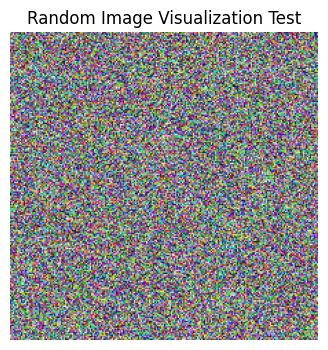


Environment setup complete.


In [1]:
# ============================================================
# STEP 1 — ENVIRONMENT SETUP
# ============================================================

# -------------------------------
# Install any missing libraries
# -------------------------------
!pip install -q opencv-python seaborn scikit-learn

# -------------------------------
# Import libraries
# -------------------------------
import os
import random
import numpy as np
import cv2
import torch
import torchvision
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

print("Libraries imported successfully.\n")

# -------------------------------
# Print library versions
# -------------------------------
print("Library Versions")
print("------------------")
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("NumPy:", np.__version__)
print("OpenCV:", cv2.__version__)
print("Seaborn:", sns.__version__)

# -------------------------------
# Set Random Seeds (Reproducibility)
# -------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Ensure deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

print("\nRandom seeds set to:", SEED)

# -------------------------------
# Detect GPU
# -------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\nDevice Information")
print("------------------")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Memory Allocated:", torch.cuda.memory_allocated(0) / 1024**2, "MB")
    print("GPU Memory Reserved:", torch.cuda.memory_reserved(0) / 1024**2, "MB")
else:
    print("CUDA not available. Running on CPU.")

# -------------------------------
# Verify Tensor Operations
# -------------------------------
print("\nTensor Test")
print("------------------")

test_tensor = torch.randn(4, 3, 224, 224).to(device)

print("Test tensor shape:", test_tensor.shape)
print("Tensor device:", test_tensor.device)

# -------------------------------
# Visualization Test
# -------------------------------
print("\nMatplotlib Test")

sample_image = np.random.rand(224,224,3)

plt.figure(figsize=(4,4))
plt.imshow(sample_image)
plt.title("Random Image Visualization Test")
plt.axis("off")
plt.show()

print("\nEnvironment setup complete.")

In [2]:
import os

print("Available datasets in /kaggle/input:\n")

for dataset in os.listdir("/kaggle/input"):
    print(dataset)

Available datasets in /kaggle/input:

datasets


In [3]:
import os

DATA_ROOT = "/kaggle/input/datasets"

print("Folders inside /kaggle/input/datasets:\n")

for item in os.listdir(DATA_ROOT):
    print(item)

Folders inside /kaggle/input/datasets:

ziya07


In [4]:
import os

DATA_PATH = "/kaggle/input/datasets/ziya07"

print("Contents of dataset folder:\n")

for item in os.listdir(DATA_PATH):
    print(item)

Contents of dataset folder:

multimodal-biometric-dataset-mulb


In [5]:
import os

DATASET_PATH = "/kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb"

print("Top level folders:\n")

for person in os.listdir(DATASET_PATH):
    person_path = os.path.join(DATASET_PATH, person)
    print(person)

    if os.path.isdir(person_path):
        print("   contains:")
        for item in os.listdir(person_path):
            print("      ", item)
        print()

Top level folders:

archive (1)
   contains:
       Faces
       Original Images
       Dataset.csv

archive
   contains:
       face samples.png
       MULB dataset
       iris samples.png
       hand samples.png



In [6]:
import os

DATASET_PATH = "/kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset"

print("Dataset path:", DATASET_PATH)
print("\nFirst few folders inside dataset:\n")

folders = os.listdir(DATASET_PATH)

for f in folders[:10]:
    print(f)

Dataset path: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset

First few folders inside dataset:

hand dataset
iris dataset


Base dataset path: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset

Total Iris Identities: 188
Total Palm Identities: 188

Common identities (usable for multimodal): 188

DATASET STATISTICS
---------------------
Total identities: 188
Total iris images: 3759
Total palm images: 3948
Average iris images per identity: 19.99468085106383
Average palm images per identity: 21.0

IMAGE SHAPES
Iris image shape: (862, 1610, 3)
Palm image shape: (2317, 2747, 3)


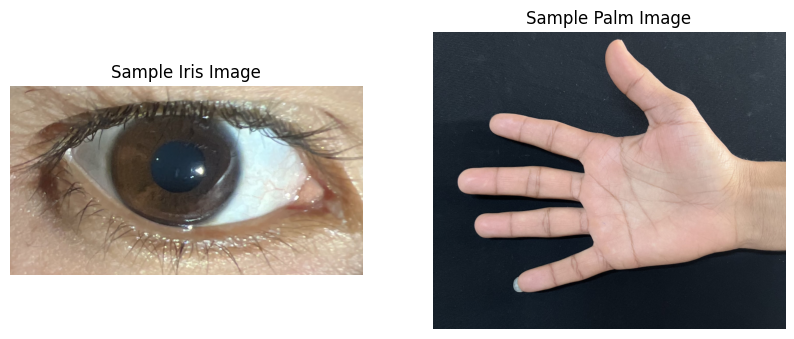

In [7]:
# ============================================================
# STEP 2 — SCAN MULB DATASET (CORRECT STRUCTURE)
# ============================================================

import os
import cv2
import matplotlib.pyplot as plt

BASE_PATH = "/kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset"

IRIS_PATH = os.path.join(BASE_PATH, "iris dataset")
PALM_PATH = os.path.join(BASE_PATH, "hand dataset")

print("Base dataset path:", BASE_PATH)

# ------------------------------------------------
# Scan identities
# ------------------------------------------------

iris_ids = sorted(os.listdir(IRIS_PATH))
palm_ids = sorted(os.listdir(PALM_PATH))

print("\nTotal Iris Identities:", len(iris_ids))
print("Total Palm Identities:", len(palm_ids))

# ------------------------------------------------
# Find common identities
# ------------------------------------------------

common_ids = sorted(list(set(iris_ids) & set(palm_ids)))

print("\nCommon identities (usable for multimodal):", len(common_ids))

# ------------------------------------------------
# Count images
# ------------------------------------------------

iris_images = []
palm_images = []

for person in common_ids:

    iris_folder = os.path.join(IRIS_PATH, person)
    palm_folder = os.path.join(PALM_PATH, person)

    iris_files = os.listdir(iris_folder)
    palm_files = os.listdir(palm_folder)

    for f in iris_files:
        iris_images.append(os.path.join(iris_folder, f))

    for f in palm_files:
        palm_images.append(os.path.join(palm_folder, f))

print("\nDATASET STATISTICS")
print("---------------------")

print("Total identities:", len(common_ids))
print("Total iris images:", len(iris_images))
print("Total palm images:", len(palm_images))

print("Average iris images per identity:", len(iris_images)/len(common_ids))
print("Average palm images per identity:", len(palm_images)/len(common_ids))

# ------------------------------------------------
# Load sample images
# ------------------------------------------------

sample_iris = iris_images[0]
sample_palm = palm_images[0]

iris_img = cv2.imread(sample_iris)
iris_img = cv2.cvtColor(iris_img, cv2.COLOR_BGR2RGB)

palm_img = cv2.imread(sample_palm)
palm_img = cv2.cvtColor(palm_img, cv2.COLOR_BGR2RGB)

print("\nIMAGE SHAPES")
print("Iris image shape:", iris_img.shape)
print("Palm image shape:", palm_img.shape)

# ------------------------------------------------
# Visualization
# ------------------------------------------------

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(iris_img)
plt.title("Sample Iris Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(palm_img)
plt.title("Sample Palm Image")
plt.axis("off")

plt.show()

IDENTITY SPLIT
------------------
Train identities: 131
Validation identities: 28
Test identities: 29

IMAGE TRANSFORMATION
----------------------
Original Iris Shape: (862, 1610, 3)
Processed Iris Shape: (224, 224, 3)
Original Palm Shape: (2317, 2747, 3)
Processed Palm Shape: (224, 224, 3)

Pixel value range after normalization:
Min: 0.0196078431372549 Max: 1.0


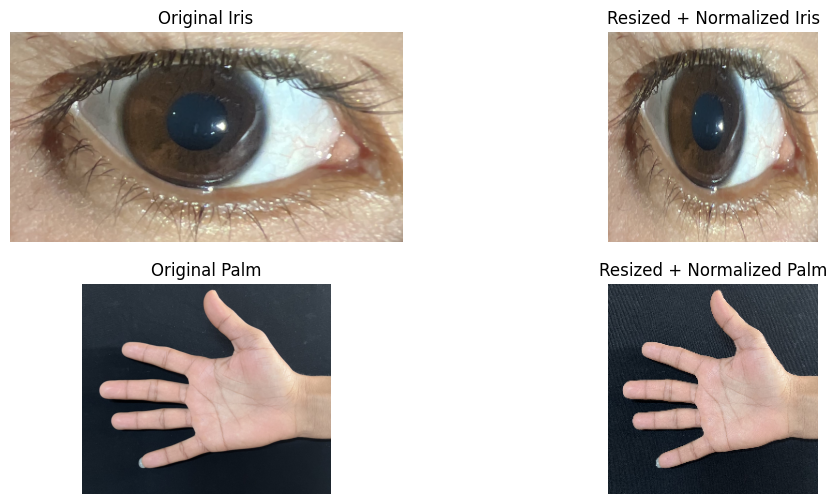

In [8]:
# ============================================================
# STEP 3 — DATA SPLITTING + PREPROCESSING
# ============================================================

import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ------------------------------------------------
# Identity split
# ------------------------------------------------

identities = common_ids

train_ids, temp_ids = train_test_split(
    identities,
    test_size=0.30,
    random_state=42
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

print("IDENTITY SPLIT")
print("------------------")

print("Train identities:", len(train_ids))
print("Validation identities:", len(val_ids))
print("Test identities:", len(test_ids))

# ------------------------------------------------
# Image preprocessing function
# ------------------------------------------------

def preprocess_image(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    original_shape = img.shape

    # Resize to MobileNet size
    img = cv2.resize(img, (224,224))

    # Normalize
    img = img / 255.0

    return img, original_shape


# ------------------------------------------------
# Test preprocessing on sample images
# ------------------------------------------------

sample_iris = iris_images[0]
sample_palm = palm_images[0]

iris_processed, iris_original_shape = preprocess_image(sample_iris)
palm_processed, palm_original_shape = preprocess_image(sample_palm)

print("\nIMAGE TRANSFORMATION")
print("----------------------")

print("Original Iris Shape:", iris_original_shape)
print("Processed Iris Shape:", iris_processed.shape)

print("Original Palm Shape:", palm_original_shape)
print("Processed Palm Shape:", palm_processed.shape)

print("\nPixel value range after normalization:")
print("Min:", iris_processed.min(), "Max:", iris_processed.max())

# ------------------------------------------------
# Visualization
# ------------------------------------------------

plt.figure(figsize=(12,6))

# Iris original
plt.subplot(2,2,1)
plt.imshow(cv2.cvtColor(cv2.imread(sample_iris), cv2.COLOR_BGR2RGB))
plt.title("Original Iris")
plt.axis("off")

# Iris processed
plt.subplot(2,2,2)
plt.imshow(iris_processed)
plt.title("Resized + Normalized Iris")
plt.axis("off")

# Palm original
plt.subplot(2,2,3)
plt.imshow(cv2.cvtColor(cv2.imread(sample_palm), cv2.COLOR_BGR2RGB))
plt.title("Original Palm")
plt.axis("off")

# Palm processed
plt.subplot(2,2,4)
plt.imshow(palm_processed)
plt.title("Resized + Normalized Palm")
plt.axis("off")

plt.show()

TOTAL MULTIMODAL PAIRS CREATED: 3759

Sample Pair Label (Person ID): CC
Iris path: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset/iris dataset/CC/1.jpg
Palm path: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset/hand dataset/CC/IMG_6387.jpg


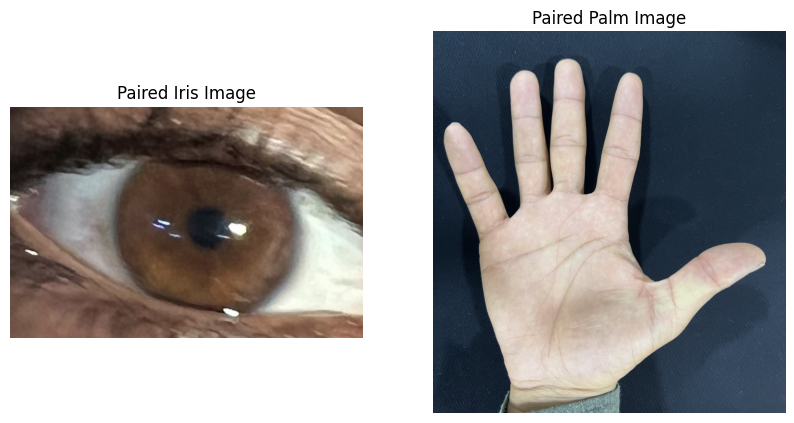

In [9]:
# ============================================================
# STEP 4 — CREATE IRIS + PALM PAIRS
# ============================================================

import random
import matplotlib.pyplot as plt
import cv2

pairs = []
labels = []

# ------------------------------------------------
# Create multimodal pairs
# ------------------------------------------------

for person in common_ids:

    iris_folder = os.path.join(IRIS_PATH, person)
    palm_folder = os.path.join(PALM_PATH, person)

    iris_files = os.listdir(iris_folder)
    palm_files = os.listdir(palm_folder)

    iris_paths = [os.path.join(iris_folder, f) for f in iris_files]
    palm_paths = [os.path.join(palm_folder, f) for f in palm_files]

    # Pair each iris with a random palm from same identity
    for iris_img in iris_paths:

        palm_img = random.choice(palm_paths)

        pairs.append((iris_img, palm_img))
        labels.append(person)

print("TOTAL MULTIMODAL PAIRS CREATED:", len(pairs))

# ------------------------------------------------
# Display sample pairs
# ------------------------------------------------

sample_index = random.randint(0, len(pairs)-1)

sample_iris_path, sample_palm_path = pairs[sample_index]

iris_img = cv2.cvtColor(cv2.imread(sample_iris_path), cv2.COLOR_BGR2RGB)
palm_img = cv2.cvtColor(cv2.imread(sample_palm_path), cv2.COLOR_BGR2RGB)

print("\nSample Pair Label (Person ID):", labels[sample_index])

print("Iris path:", sample_iris_path)
print("Palm path:", sample_palm_path)

# ------------------------------------------------
# Visualization
# ------------------------------------------------

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(iris_img)
plt.title("Paired Iris Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(palm_img)
plt.title("Paired Palm Image")
plt.axis("off")

plt.show()

Total classes: 188
Dataset size: 3759

BATCH SHAPES
--------------------
Iris batch shape: torch.Size([32, 3, 224, 224])
Palm batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])

Label range check
Min label: 5
Max label: 184


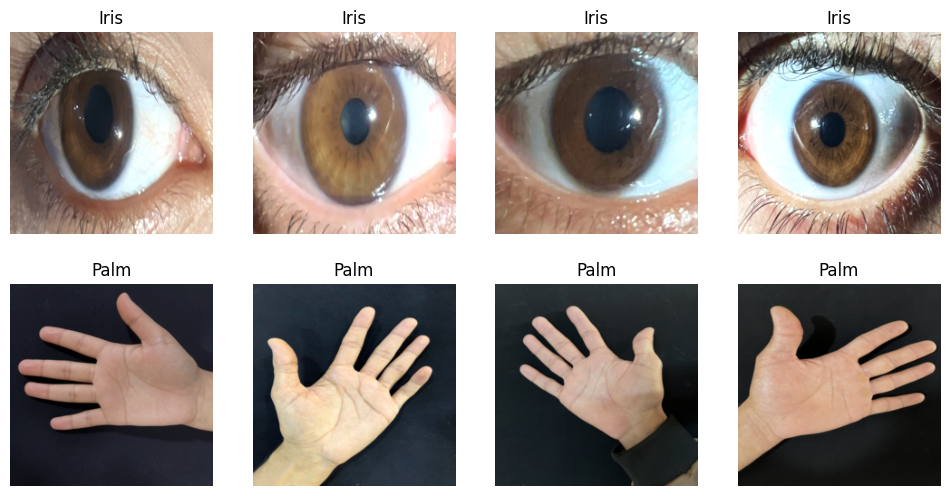

In [10]:
# ============================================================
# STEP 5 — PYTORCH DATASET + DATALOADER (ROBUST VERSION)
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2
import numpy as np

# ------------------------------------------------
# Transform pipeline
# ------------------------------------------------

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

# ------------------------------------------------
# Create label mapping (person_id → class index)
# ------------------------------------------------

unique_ids = sorted(list(set(labels)))
label_to_idx = {pid: idx for idx, pid in enumerate(unique_ids)}

print("Total classes:", len(label_to_idx))

# ------------------------------------------------
# Custom Dataset
# ------------------------------------------------

class MultimodalDataset(Dataset):

    def __init__(self, pairs, labels, transform=None):
        self.pairs = pairs
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):

        iris_path, palm_path = self.pairs[idx]
        person_id = self.labels[idx]

        iris = cv2.imread(iris_path)
        palm = cv2.imread(palm_path)

        # ------------------------------------------------
        # Handle broken images safely
        # ------------------------------------------------

        if iris is None or palm is None:

            print("⚠ Broken image detected")
            print("Iris:", iris_path)
            print("Palm:", palm_path)

            # create dummy images instead of crashing
            iris = np.zeros((224,224,3), dtype=np.uint8)
            palm = np.zeros((224,224,3), dtype=np.uint8)

        else:

            iris = cv2.cvtColor(iris, cv2.COLOR_BGR2RGB)
            palm = cv2.cvtColor(palm, cv2.COLOR_BGR2RGB)

        # ------------------------------------------------
        # Apply transforms
        # ------------------------------------------------

        if self.transform:
            iris = self.transform(iris)
            palm = self.transform(palm)

        # ------------------------------------------------
        # Convert person ID → class index
        # ------------------------------------------------

        label = torch.tensor(label_to_idx[person_id], dtype=torch.long)

        return iris, palm, label


# ------------------------------------------------
# Create dataset
# ------------------------------------------------

dataset = MultimodalDataset(pairs, labels, transform)

print("Dataset size:", len(dataset))

# ------------------------------------------------
# Create DataLoader
# ------------------------------------------------

batch_size = 32

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)

# ------------------------------------------------
# Inspect batch
# ------------------------------------------------

iris_batch, palm_batch, label_batch = next(iter(dataloader))

print("\nBATCH SHAPES")
print("--------------------")

print("Iris batch shape:", iris_batch.shape)
print("Palm batch shape:", palm_batch.shape)
print("Label batch shape:", label_batch.shape)

print("\nLabel range check")
print("Min label:", label_batch.min().item())
print("Max label:", label_batch.max().item())

# ------------------------------------------------
# Visualization
# ------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for i in range(4):

    plt.subplot(2,4,i+1)
    plt.imshow(iris_batch[i].permute(1,2,0))
    plt.title("Iris")
    plt.axis("off")

    plt.subplot(2,4,i+5)
    plt.imshow(palm_batch[i].permute(1,2,0))
    plt.title("Palm")
    plt.axis("off")

plt.show()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 117MB/s] 


MobileNetV2 Feature Extractor Loaded

FEATURE MAP SHAPES
----------------------
Iris feature map: torch.Size([32, 1280, 7, 7])
Palm feature map: torch.Size([32, 1280, 7, 7])


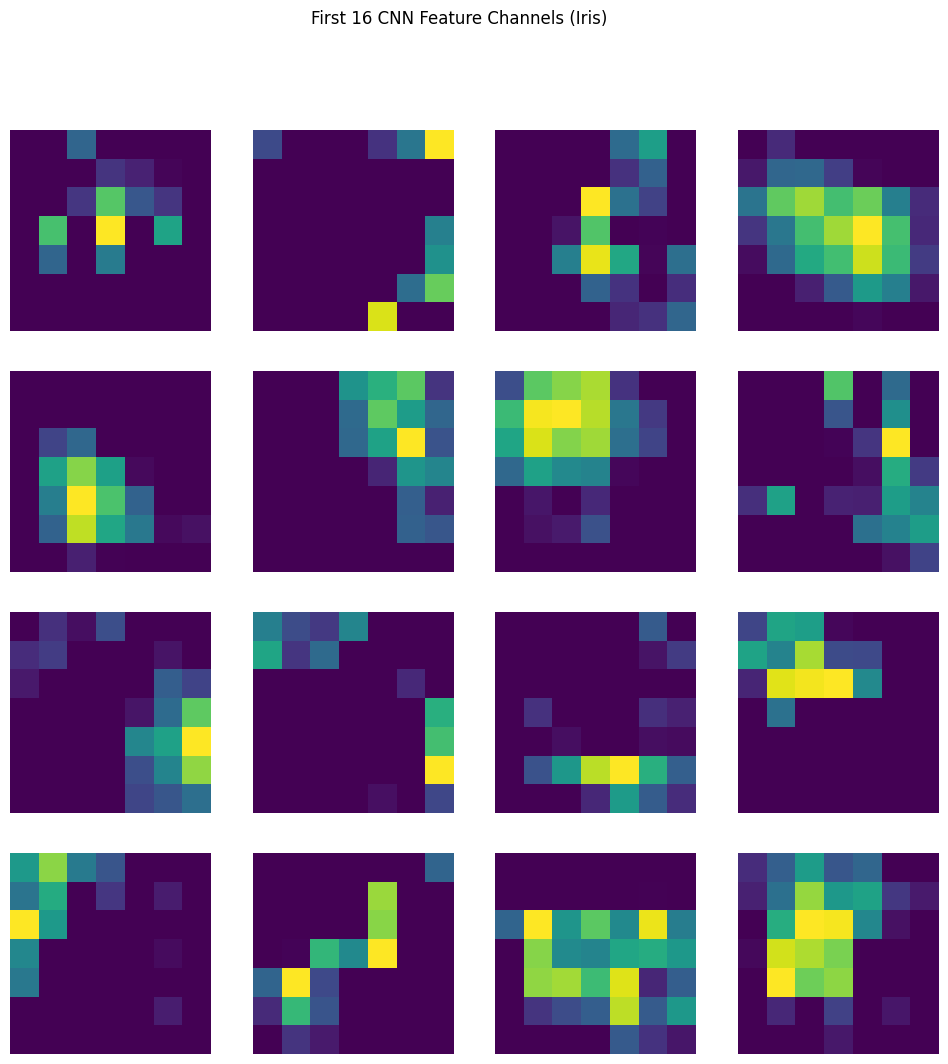

In [11]:
# ============================================================
# STEP 6 — MOBILENETV2 BACKBONE
# ============================================================

import torch
import torchvision.models as models

# ------------------------------------------------
# Load pretrained MobileNetV2
# ------------------------------------------------

mobilenet = models.mobilenet_v2(pretrained=True)

# Remove classifier layer
feature_extractor = mobilenet.features

feature_extractor = feature_extractor.to(device)

print("MobileNetV2 Feature Extractor Loaded\n")

# ------------------------------------------------
# Forward pass with sample batch
# ------------------------------------------------

iris_features = feature_extractor(iris_batch.to(device))
palm_features = feature_extractor(palm_batch.to(device))

print("FEATURE MAP SHAPES")
print("----------------------")

print("Iris feature map:", iris_features.shape)
print("Palm feature map:", palm_features.shape)

# ------------------------------------------------
# Visualize CNN feature maps
# ------------------------------------------------

import matplotlib.pyplot as plt

feature_map = iris_features[0].detach().cpu()

plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(feature_map[i], cmap='viridis')
    plt.axis("off")

plt.suptitle("First 16 CNN Feature Channels (Iris)")
plt.show()

INCEPTION OUTPUT SHAPES
---------------------------
Iris: torch.Size([32, 256, 7, 7])
Palm: torch.Size([32, 256, 7, 7])


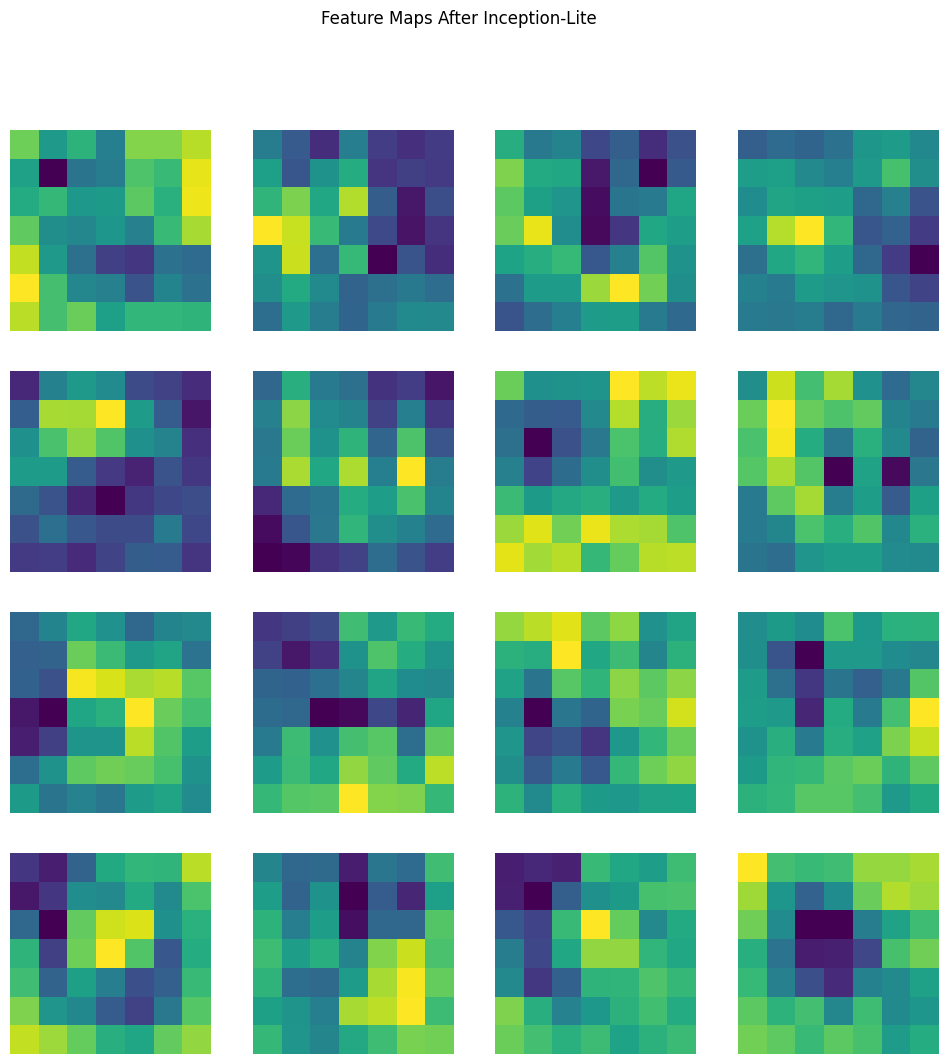

In [12]:
# ============================================================
# STEP 7 — INCEPTION-LITE BLOCK
# ============================================================

import torch
import torch.nn as nn

# Ensure device exists
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class InceptionLite(nn.Module):

    def __init__(self, in_channels=1280, out_channels=256):

        super(InceptionLite, self).__init__()

        branch_channels = out_channels // 4

        self.branch1 = nn.Conv2d(in_channels, branch_channels, kernel_size=1)

        self.branch3 = nn.Conv2d(in_channels, branch_channels, kernel_size=3, padding=1)

        self.branch5 = nn.Conv2d(in_channels, branch_channels, kernel_size=5, padding=2)

        self.branch_pool = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, branch_channels, kernel_size=1)
        )

    def forward(self, x):

        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.branch_pool(x)

        output = torch.cat([b1, b3, b5, bp], dim=1)

        return output


# ------------------------------------------------
# Initialize block
# ------------------------------------------------

inception_block = InceptionLite().to(device)

# ------------------------------------------------
# Forward pass
# ------------------------------------------------

iris_inception = inception_block(iris_features)
palm_inception = inception_block(palm_features)

print("INCEPTION OUTPUT SHAPES")
print("---------------------------")

print("Iris:", iris_inception.shape)
print("Palm:", palm_inception.shape)

# ------------------------------------------------
# Visualize feature maps
# ------------------------------------------------

import matplotlib.pyplot as plt

feature_map = iris_inception[0].detach().cpu()

plt.figure(figsize=(12,12))

for i in range(16):

    plt.subplot(4,4,i+1)
    plt.imshow(feature_map[i], cmap='viridis')
    plt.axis("off")

plt.suptitle("Feature Maps After Inception-Lite")
plt.show()

In [13]:
# ============================================================
# STEP 8 — CBAM ATTENTION MODULE
# ============================================================

import torch.nn as nn
import torch

# ------------------------------------------------
# Channel Attention
# ------------------------------------------------

class ChannelAttention(nn.Module):

    def __init__(self, in_channels, reduction=16):
        super(ChannelAttention, self).__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))

        out = avg_out + max_out

        return self.sigmoid(out)


# ------------------------------------------------
# Spatial Attention
# ------------------------------------------------

class SpatialAttention(nn.Module):

    def __init__(self):
        super(SpatialAttention, self).__init__()

        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)

        x = self.conv(x)

        return self.sigmoid(x)


# ------------------------------------------------
# CBAM Block
# ------------------------------------------------

class CBAM(nn.Module):

    def __init__(self, in_channels):
        super(CBAM, self).__init__()

        self.channel_attention = ChannelAttention(in_channels)
        self.spatial_attention = SpatialAttention()

    def forward(self, x):

        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)

        return x


# ------------------------------------------------
# Initialize CBAM
# ------------------------------------------------

cbam = CBAM(256).to(device)

# ------------------------------------------------
# Forward pass
# ------------------------------------------------

iris_cbam = cbam(iris_inception)
palm_cbam = cbam(palm_inception)

print("CBAM OUTPUT SHAPES")
print("---------------------")

print("Iris:", iris_cbam.shape)
print("Palm:", palm_cbam.shape)

CBAM OUTPUT SHAPES
---------------------
Iris: torch.Size([32, 256, 7, 7])
Palm: torch.Size([32, 256, 7, 7])


In [14]:
# ============================================================
# STEP 9 — GLOBAL AVERAGE POOLING
# ============================================================

import torch.nn as nn

# ------------------------------------------------
# Global Average Pooling Layer
# ------------------------------------------------

gap = nn.AdaptiveAvgPool2d((1,1))

# ------------------------------------------------
# Apply pooling
# ------------------------------------------------

iris_gap = gap(iris_cbam)
palm_gap = gap(palm_cbam)

print("AFTER GLOBAL AVERAGE POOLING")
print("------------------------------")

print("Iris:", iris_gap.shape)
print("Palm:", palm_gap.shape)

# ------------------------------------------------
# Flatten embeddings
# ------------------------------------------------

iris_embedding = iris_gap.view(iris_gap.size(0), -1)
palm_embedding = palm_gap.view(palm_gap.size(0), -1)

print("\nFLATTENED EMBEDDINGS")

print("Iris embedding shape:", iris_embedding.shape)
print("Palm embedding shape:", palm_embedding.shape)

# ------------------------------------------------
# Inspect sample embedding
# ------------------------------------------------

print("\nSample Iris Embedding (first 10 values):")
print(iris_embedding[0][:10])

print("\nEmbedding vector length:", iris_embedding.shape[1])

AFTER GLOBAL AVERAGE POOLING
------------------------------
Iris: torch.Size([32, 256, 1, 1])
Palm: torch.Size([32, 256, 1, 1])

FLATTENED EMBEDDINGS
Iris embedding shape: torch.Size([32, 256])
Palm embedding shape: torch.Size([32, 256])

Sample Iris Embedding (first 10 values):
tensor([-0.1154,  0.0708,  0.0584,  0.0404,  0.0863,  0.2383, -0.1399,  0.0663,
         0.0059, -0.0867], device='cuda:0', grad_fn=<SliceBackward0>)

Embedding vector length: 256


In [15]:
# ============================================================
# STEP 10 — MULTIMODAL FUSION
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

# ------------------------------------------------
# Concatenate embeddings
# ------------------------------------------------

fusion_input = torch.cat([iris_embedding, palm_embedding], dim=1)

print("FUSION INPUT SHAPE")
print("--------------------")

print("Concatenated embedding:", fusion_input.shape)


# ------------------------------------------------
# Fusion Fully Connected Layer
# ------------------------------------------------

fusion_fc = nn.Linear(512, 256).to(device)

fused_embedding = fusion_fc(fusion_input)

print("\nAFTER FUSION FC LAYER")
print("----------------------")

print("Fused embedding shape:", fused_embedding.shape)


# ------------------------------------------------
# L2 Normalization
# ------------------------------------------------

normalized_embedding = F.normalize(fused_embedding, p=2, dim=1)

print("\nAFTER L2 NORMALIZATION")
print("----------------------")

print("Normalized embedding shape:", normalized_embedding.shape)


# ------------------------------------------------
# Check embedding norms
# ------------------------------------------------

norms = torch.norm(normalized_embedding, dim=1)

print("\nEmbedding norms (first 5):")
print(norms[:5])

FUSION INPUT SHAPE
--------------------
Concatenated embedding: torch.Size([32, 512])

AFTER FUSION FC LAYER
----------------------
Fused embedding shape: torch.Size([32, 256])

AFTER L2 NORMALIZATION
----------------------
Normalized embedding shape: torch.Size([32, 256])

Embedding norms (first 5):
tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000], device='cuda:0',
       grad_fn=<SliceBackward0>)


In [16]:
# ============================================================
# STEP 11 — ARCFACE LOSS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F

class ArcFace(nn.Module):

    def __init__(self, embedding_size, num_classes, s=30.0, m=0.5):
        super(ArcFace, self).__init__()

        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)

    def forward(self, embeddings, labels):

        embeddings = F.normalize(embeddings)
        weights = F.normalize(self.weight)

        cosine = F.linear(embeddings, weights)

        theta = torch.acos(torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7))
        target_logits = torch.cos(theta + self.m)

        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1,1), 1)

        logits = cosine * (1 - one_hot) + target_logits * one_hot
        logits *= self.s

        return logits


# ------------------------------------------------
# Initialize ArcFace
# ------------------------------------------------

num_classes = len(common_ids)

arcface = ArcFace(embedding_size=256, num_classes=num_classes).to(device)

# ------------------------------------------------
# Convert labels to numeric IDs
# ------------------------------------------------

label_to_id = {label:i for i,label in enumerate(common_ids)}
numeric_labels = torch.tensor([label_to_id[l] for l in labels[:32]]).to(device)

# ------------------------------------------------
# Forward pass
# ------------------------------------------------

logits = arcface(normalized_embedding, numeric_labels)

print("ARCFACE LOGITS SHAPE")
print("---------------------")

print(logits.shape)

ARCFACE LOGITS SHAPE
---------------------
torch.Size([32, 188])


In [17]:
# ============================================================
# STEP 12 — TRAINING LOOP (FINAL VERSION)
# ============================================================
'''
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.amp import GradScaler, autocast

# ------------------------------------------------
# Loss function
# ------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------
# Optimizer
# ------------------------------------------------

optimizer = optim.AdamW(
    list(feature_extractor.parameters()) +
    list(inception_block.parameters()) +
    list(cbam.parameters()) +
    list(fusion_fc.parameters()) +
    list(arcface.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

# ------------------------------------------------
# Scheduler
# ------------------------------------------------

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=20
)

# ------------------------------------------------
# Mixed precision scaler
# ------------------------------------------------

scaler = GradScaler("cuda")

# ------------------------------------------------
# Training configuration
# ------------------------------------------------

epochs = 20

print("\nTRAINING CONFIGURATION")
print("----------------------")

print("Epochs:", epochs)
print("Optimizer: AdamW")
print("Scheduler: CosineAnnealingLR")
print("Mixed Precision: Enabled")

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    running_loss = 0
    correct = 0
    total = 0

    for iris_batch, palm_batch, label_batch in dataloader:

        iris_batch = iris_batch.to(device)
        palm_batch = palm_batch.to(device)

        # labels already 0–187
        numeric_labels = label_batch.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):

            # -----------------------------
            # Feature extraction
            # -----------------------------

            iris_features = feature_extractor(iris_batch)
            palm_features = feature_extractor(palm_batch)

            # -----------------------------
            # Inception block
            # -----------------------------

            iris_inc = inception_block(iris_features)
            palm_inc = inception_block(palm_features)

            # -----------------------------
            # CBAM attention
            # -----------------------------

            iris_att = cbam(iris_inc)
            palm_att = cbam(palm_inc)

            # -----------------------------
            # Global Average Pooling
            # -----------------------------

            iris_gap = gap(iris_att).view(iris_batch.size(0), -1)
            palm_gap = gap(palm_att).view(palm_batch.size(0), -1)

            # -----------------------------
            # Multimodal Fusion
            # -----------------------------

            fusion_input = torch.cat([iris_gap, palm_gap], dim=1)

            fused = fusion_fc(fusion_input)

            embeddings = F.normalize(fused)

            # -----------------------------
            # ArcFace
            # -----------------------------

            logits = arcface(embeddings, numeric_labels)

            loss = criterion(logits, numeric_labels)

        # -----------------------------
        # Backpropagation
        # -----------------------------

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

        # -----------------------------
        # Accuracy
        # -----------------------------

        preds = torch.argmax(logits, dim=1)

        correct += (preds == numeric_labels).sum().item()
        total += numeric_labels.size(0)

    scheduler.step()

    epoch_loss = running_loss
    epoch_acc = 100 * correct / total

    print(f"\nEpoch {epoch+1}/{epochs}")
    print("Loss:", round(epoch_loss,2))
    print("Accuracy:", round(epoch_acc,2), "%")

    print("GPU Memory:",
          round(torch.cuda.memory_allocated()/1024**2,2), "MB")

print("\nTRAINING COMPLETE")
'''

'\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nimport torch.optim as optim\nfrom torch.amp import GradScaler, autocast\n\n# ------------------------------------------------\n# Loss function\n# ------------------------------------------------\n\ncriterion = nn.CrossEntropyLoss()\n\n# ------------------------------------------------\n# Optimizer\n# ------------------------------------------------\n\noptimizer = optim.AdamW(\n    list(feature_extractor.parameters()) +\n    list(inception_block.parameters()) +\n    list(cbam.parameters()) +\n    list(fusion_fc.parameters()) +\n    list(arcface.parameters()),\n    lr=1e-4,\n    weight_decay=1e-4\n)\n\n# ------------------------------------------------\n# Scheduler\n# ------------------------------------------------\n\nscheduler = torch.optim.lr_scheduler.CosineAnnealingLR(\n    optimizer,\n    T_max=20\n)\n\n# ------------------------------------------------\n# Mixed precision scaler\n# ----------------------------

In [18]:
# ============================================================
# SAVE TRAINED MODEL
# ============================================================

save_path = "/kaggle/working/biometric_model.pth"

torch.save({
    'mobilenet': feature_extractor.state_dict(),
    'inception': inception_block.state_dict(),
    'cbam': cbam.state_dict(),
    'fusion_fc': fusion_fc.state_dict(),
    'arcface': arcface.state_dict()
}, save_path)

print("Model saved successfully at:", save_path)

Model saved successfully at: /kaggle/working/biometric_model.pth


In [19]:
# ============================================================
# RECREATE MODEL ARCHITECTURE
# ============================================================

# set models to device
feature_extractor = feature_extractor.to(device)
inception_block = inception_block.to(device)
cbam = cbam.to(device)
fusion_fc = fusion_fc.to(device)
arcface = arcface.to(device)

print("Model architecture recreated.")

Model architecture recreated.


In [20]:
# ============================================================
# LOAD SAVED MODEL
# ============================================================

checkpoint = torch.load("/kaggle/working/biometric_model.pth", map_location=device)

feature_extractor.load_state_dict(checkpoint['mobilenet'])
inception_block.load_state_dict(checkpoint['inception'])
cbam.load_state_dict(checkpoint['cbam'])
fusion_fc.load_state_dict(checkpoint['fusion_fc'])
arcface.load_state_dict(checkpoint['arcface'])

print("Model weights loaded successfully.")

Model weights loaded successfully.


In [21]:
feature_extractor.eval()
inception_block.eval()
cbam.eval()
fusion_fc.eval()

print("Model set to evaluation mode.")

Model set to evaluation mode.


In [22]:
# ============================================================
# STEP 13 — GENERATE EMBEDDINGS FOR EVALUATION
# ============================================================

import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

feature_extractor.eval()
inception_block.eval()
cbam.eval()
fusion_fc.eval()

all_embeddings = []
all_labels = []

with torch.no_grad():

    for iris_batch, palm_batch, label_batch in dataloader:

        iris_batch = iris_batch.to(device)
        palm_batch = palm_batch.to(device)

        iris_features = feature_extractor(iris_batch)
        palm_features = feature_extractor(palm_batch)

        iris_inc = inception_block(iris_features)
        palm_inc = inception_block(palm_features)

        iris_att = cbam(iris_inc)
        palm_att = cbam(palm_inc)

        iris_gap = gap(iris_att).view(iris_batch.size(0), -1)
        palm_gap = gap(palm_att).view(palm_batch.size(0), -1)

        fusion_input = torch.cat([iris_gap, palm_gap], dim=1)

        fused = fusion_fc(fusion_input)

        embeddings = F.normalize(fused)

        all_embeddings.append(embeddings.cpu())
        all_labels.append(label_batch)

all_embeddings = torch.cat(all_embeddings).numpy()
all_labels = torch.cat(all_labels).numpy()

print("Embeddings shape:", all_embeddings.shape)
print("Labels shape:", all_labels.shape)

⚠ Broken image detected
Iris: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset/iris dataset/FY/16.jpg
Palm: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset/hand dataset/FY/P
⚠ Broken image detected
Iris: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset/iris dataset/FY/17.jpg
Palm: /kaggle/input/datasets/ziya07/multimodal-biometric-dataset-mulb/archive/MULB dataset/hand dataset/FY/R
Embeddings shape: (3759, 256)
Labels shape: (3759,)


In [23]:
# ============================================================
# COMPUTE COSINE SIMILARITIES
# ============================================================

genuine_scores = []
imposter_scores = []

for i in range(len(all_embeddings)):
    for j in range(i+1, len(all_embeddings)):

        sim = cosine_similarity(
            [all_embeddings[i]],
            [all_embeddings[j]]
        )[0][0]

        if all_labels[i] == all_labels[j]:
            genuine_scores.append(sim)
        else:
            imposter_scores.append(sim)

print("Genuine pairs:", len(genuine_scores))
print("Imposter pairs:", len(imposter_scores))

print("\nAverage Genuine Similarity:", np.mean(genuine_scores))
print("Average Imposter Similarity:", np.mean(imposter_scores))

Genuine pairs: 35701
Imposter pairs: 7027460

Average Genuine Similarity: 0.9291562
Average Imposter Similarity: 0.86690325


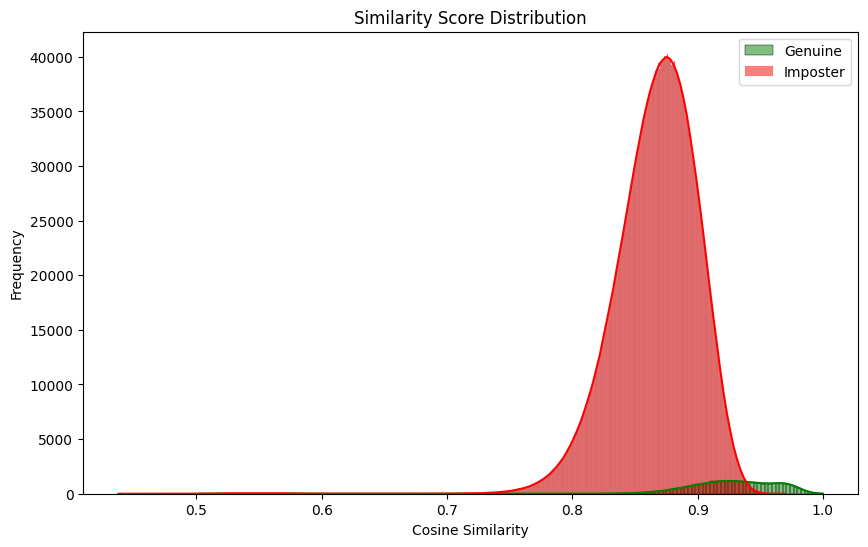

In [24]:
# ============================================================
# PLOT SIMILARITY DISTRIBUTIONS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.histplot(genuine_scores, color="green", label="Genuine", kde=True)
sns.histplot(imposter_scores, color="red", label="Imposter", kde=True)

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.title("Similarity Score Distribution")
plt.legend()

plt.show()

EER: 0.1684265723319663


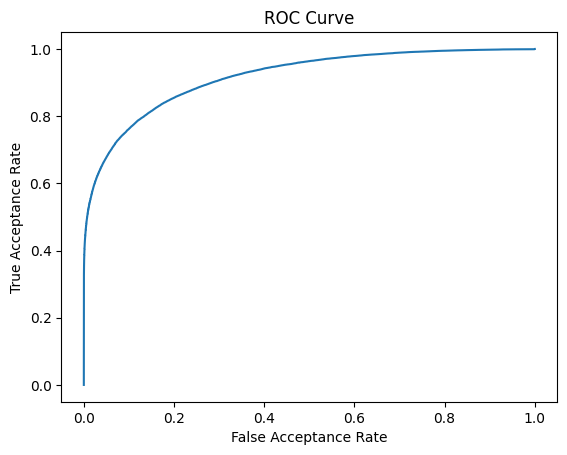

In [25]:
# ============================================================
# ROC + EER
# ============================================================

from sklearn.metrics import roc_curve

labels = np.concatenate([
    np.ones(len(genuine_scores)),
    np.zeros(len(imposter_scores))
])

scores = np.concatenate([
    genuine_scores,
    imposter_scores
])

fpr, tpr, thresholds = roc_curve(labels, scores)

fnr = 1 - tpr
eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]

print("EER:", eer)

plt.plot(fpr, tpr)
plt.xlabel("False Acceptance Rate")
plt.ylabel("True Acceptance Rate")
plt.title("ROC Curve")
plt.show()

In [26]:
# ============================================================
# STEP 14 — EMBEDDING QUALITY ANALYSIS
# ============================================================

import numpy as np

genuine_scores = np.array(genuine_scores)
imposter_scores = np.array(imposter_scores)

print("Embedding Quality Statistics")
print("--------------------------------")

print("Genuine Mean:", np.mean(genuine_scores))
print("Genuine Std:", np.std(genuine_scores))

print("Imposter Mean:", np.mean(imposter_scores))
print("Imposter Std:", np.std(imposter_scores))

# separation margin
margin = np.mean(genuine_scores) - np.mean(imposter_scores)

print("\nEmbedding Separation Margin:", margin)

Embedding Quality Statistics
--------------------------------
Genuine Mean: 0.9291562
Genuine Std: 0.034297533
Imposter Mean: 0.86690325
Imposter Std: 0.033266474

Embedding Separation Margin: 0.06225294


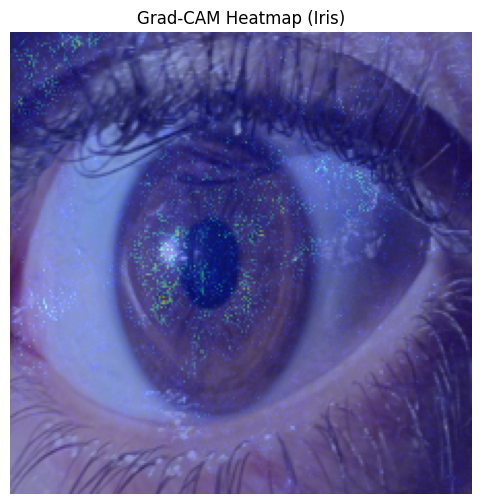

In [27]:
# ============================================================
# STEP 15 — GRAD-CAM VISUALIZATION (FIXED VERSION)
# ============================================================

import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

# ------------------------------------------------
# Grad-CAM generation function
# ------------------------------------------------

def generate_gradcam(model, image_tensor):

    model.eval()

    # add batch dimension
    image_tensor = image_tensor.unsqueeze(0).to(device)
    image_tensor.requires_grad = True

    # forward pass
    features = model(image_tensor)

    # simple scalar objective
    score = torch.mean(features)

    # backward pass
    score.backward()

    # gradients
    gradients = image_tensor.grad[0].detach().cpu().numpy()

    # compute heatmap
    heatmap = np.mean(np.abs(gradients), axis=0)

    # normalize heatmap
    heatmap = heatmap / np.max(heatmap)

    return heatmap


# ------------------------------------------------
# Select sample image
# ------------------------------------------------

sample_img = iris_batch[0]

# generate heatmap
heatmap = generate_gradcam(feature_extractor, sample_img)

# ------------------------------------------------
# Convert image tensor to numpy for plotting
# ------------------------------------------------

img = sample_img.detach().cpu().permute(1,2,0).numpy()

# ------------------------------------------------
# Plot results
# ------------------------------------------------

plt.figure(figsize=(6,6))

plt.imshow(img)
plt.imshow(heatmap, cmap="jet", alpha=0.4)

plt.title("Grad-CAM Heatmap (Iris)")
plt.axis("off")

plt.show()

In [28]:
# ============================================================
# STEP 16 — SAVE FINAL MODEL FOR DEPLOYMENT
# ============================================================

save_path = "/kaggle/working/final_biometric_model.pth"

torch.save({
    "mobilenet": feature_extractor.state_dict(),
    "inception": inception_block.state_dict(),
    "cbam": cbam.state_dict(),
    "fusion_fc": fusion_fc.state_dict()
}, save_path)

print("Final biometric model saved at:", save_path)

Final biometric model saved at: /kaggle/working/final_biometric_model.pth


In [29]:
# ============================================================
# STEP 17 — BIOMETRIC AUTHENTICATION TEST
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

def get_embedding(iris_img, palm_img):

    iris_img = iris_img.unsqueeze(0).to(device)
    palm_img = palm_img.unsqueeze(0).to(device)

    with torch.no_grad():

        iris_features = feature_extractor(iris_img)
        palm_features = feature_extractor(palm_img)

        iris_inc = inception_block(iris_features)
        palm_inc = inception_block(palm_features)

        iris_att = cbam(iris_inc)
        palm_att = cbam(palm_inc)

        iris_gap = gap(iris_att).view(1,-1)
        palm_gap = gap(palm_att).view(1,-1)

        fusion_input = torch.cat([iris_gap, palm_gap], dim=1)

        fused = fusion_fc(fusion_input)

        embedding = F.normalize(fused)

    return embedding.cpu().numpy()


# ------------------------------------------------
# Test authentication
# ------------------------------------------------

emb1 = get_embedding(iris_batch[0], palm_batch[0])
emb2 = get_embedding(iris_batch[1], palm_batch[1])

similarity = cosine_similarity(emb1, emb2)[0][0]

print("Cosine Similarity:", similarity)

# authentication threshold
threshold = 0.7

if similarity > threshold:
    print("Authentication Result: ACCEPT")
else:
    print("Authentication Result: REJECT")

Cosine Similarity: 0.89620626
Authentication Result: ACCEPT


In [30]:
# ============================================================
# TEST AUTHENTICATION WITH DIFFERENT SAMPLES
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

def get_embedding(iris_img, palm_img):

    iris_img = iris_img.unsqueeze(0).to(device)
    palm_img = palm_img.unsqueeze(0).to(device)

    with torch.no_grad():

        iris_features = feature_extractor(iris_img)
        palm_features = feature_extractor(palm_img)

        iris_inc = inception_block(iris_features)
        palm_inc = inception_block(palm_features)

        iris_att = cbam(iris_inc)
        palm_att = cbam(palm_inc)

        iris_gap = gap(iris_att).view(1,-1)
        palm_gap = gap(palm_att).view(1,-1)

        fusion_input = torch.cat([iris_gap, palm_gap], dim=1)

        fused = fusion_fc(fusion_input)

        embedding = F.normalize(fused)

    return embedding.cpu().numpy()


# ------------------------------------------------
# choose two dataset samples
# ------------------------------------------------

sample1 = dataset[0]
sample2 = dataset[50]   # change this index to test other users

iris1, palm1, label1 = sample1
iris2, palm2, label2 = sample2


# compute embeddings
emb1 = get_embedding(iris1, palm1)
emb2 = get_embedding(iris2, palm2)


# cosine similarity
similarity = cosine_similarity(emb1, emb2)[0][0]

print("Label 1:", label1.item())
print("Label 2:", label2.item())

print("\nCosine Similarity:", similarity)

threshold = 0.7

if similarity > threshold:
    print("Authentication Result: ACCEPT")
else:
    print("Authentication Result: REJECT")

Label 1: 0
Label 2: 2

Cosine Similarity: 0.9045905
Authentication Result: ACCEPT


In [31]:
import random

for i in range(5):

    idx1 = random.randint(0, len(dataset)-1)
    idx2 = random.randint(0, len(dataset)-1)

    iris1, palm1, label1 = dataset[idx1]
    iris2, palm2, label2 = dataset[idx2]

    emb1 = get_embedding(iris1, palm1)
    emb2 = get_embedding(iris2, palm2)

    sim = cosine_similarity(emb1, emb2)[0][0]

    print(f"\nTest {i+1}")
    print("Labels:", label1.item(), label2.item())
    print("Similarity:", sim)


Test 1
Labels: 78 28
Similarity: 0.87884736

Test 2
Labels: 85 40
Similarity: 0.911721

Test 3
Labels: 131 181
Similarity: 0.83009887

Test 4
Labels: 163 107
Similarity: 0.8854596

Test 5
Labels: 51 129
Similarity: 0.9072567


In [32]:
# find two samples with the same label
for i in range(len(dataset)):
    for j in range(i+1, len(dataset)):
        if dataset[i][2] == dataset[j][2]:

            iris1, palm1, label1 = dataset[i]
            iris2, palm2, label2 = dataset[j]

            emb1 = get_embedding(iris1, palm1)
            emb2 = get_embedding(iris2, palm2)

            sim = cosine_similarity(emb1, emb2)[0][0]

            print("Same Person Test")
            print("Label:", label1.item())
            print("Similarity:", sim)

            break
    break

Same Person Test
Label: 0
Similarity: 0.90840644


In [33]:
import random

for i in range(10):

    idx1 = random.randint(0, len(dataset)-1)
    idx2 = random.randint(0, len(dataset)-1)

    iris1, palm1, label1 = dataset[idx1]
    iris2, palm2, label2 = dataset[idx2]

    emb1 = get_embedding(iris1, palm1)
    emb2 = get_embedding(iris2, palm2)

    sim = cosine_similarity(emb1, emb2)[0][0]

    print(f"\nTest {i+1}")
    print("Labels:", label1.item(), label2.item())
    print("Similarity:", sim)


Test 1
Labels: 164 111
Similarity: 0.89373124

Test 2
Labels: 162 3
Similarity: 0.8907795

Test 3
Labels: 78 160
Similarity: 0.885738

Test 4
Labels: 146 73
Similarity: 0.8341312

Test 5
Labels: 98 111
Similarity: 0.89523184

Test 6
Labels: 160 99
Similarity: 0.81672466

Test 7
Labels: 70 186
Similarity: 0.9176165

Test 8
Labels: 115 102
Similarity: 0.84522116

Test 9
Labels: 65 79
Similarity: 0.8777562

Test 10
Labels: 55 36
Similarity: 0.8894087


In [34]:
count = 0

for i in range(len(dataset)):
    for j in range(i+1, len(dataset)):

        if dataset[i][2] == dataset[j][2]:

            iris1, palm1, label1 = dataset[i]
            iris2, palm2, label2 = dataset[j]

            emb1 = get_embedding(iris1, palm1)
            emb2 = get_embedding(iris2, palm2)

            sim = cosine_similarity(emb1, emb2)[0][0]

            print("Same Person Similarity:", sim)

            count += 1

            if count == 5:
                break
    if count == 5:
        break

Same Person Similarity: 0.89947873
Same Person Similarity: 0.9167283
Same Person Similarity: 0.98375046
Same Person Similarity: 0.9383912
Same Person Similarity: 0.9311548


In [35]:
# ============================================================
# SAME USER BIOMETRIC TEST (20 PAIRS)
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

genuine_tests = 0
target_tests = 20

for i in range(len(dataset)):
    
    for j in range(i+1, len(dataset)):
        
        iris1, palm1, label1 = dataset[i]
        iris2, palm2, label2 = dataset[j]

        # check if same user
        if label1 == label2:

            emb1 = get_embedding(iris1, palm1)
            emb2 = get_embedding(iris2, palm2)

            similarity = cosine_similarity(emb1, emb2)[0][0]

            print(f"\nTest {genuine_tests+1}")
            print("User Label:", label1.item())
            print("Similarity:", similarity)

            # authentication decision
            threshold = 0.7

            if similarity > threshold:
                print("Result: ACCEPT (Same User)")
            else:
                print("Result: REJECT")

            genuine_tests += 1

            if genuine_tests == target_tests:
                break

    if genuine_tests == target_tests:
        break


Test 1
User Label: 0
Similarity: 0.90813684
Result: ACCEPT (Same User)

Test 2
User Label: 0
Similarity: 0.9207516
Result: ACCEPT (Same User)

Test 3
User Label: 0
Similarity: 0.98747164
Result: ACCEPT (Same User)

Test 4
User Label: 0
Similarity: 0.93134356
Result: ACCEPT (Same User)

Test 5
User Label: 0
Similarity: 0.9352795
Result: ACCEPT (Same User)

Test 6
User Label: 0
Similarity: 0.9353703
Result: ACCEPT (Same User)

Test 7
User Label: 0
Similarity: 0.9534726
Result: ACCEPT (Same User)

Test 8
User Label: 0
Similarity: 0.9179698
Result: ACCEPT (Same User)

Test 9
User Label: 0
Similarity: 0.981274
Result: ACCEPT (Same User)

Test 10
User Label: 0
Similarity: 0.9377581
Result: ACCEPT (Same User)

Test 11
User Label: 0
Similarity: 0.9496161
Result: ACCEPT (Same User)

Test 12
User Label: 0
Similarity: 0.9737906
Result: ACCEPT (Same User)

Test 13
User Label: 0
Similarity: 0.9386065
Result: ACCEPT (Same User)

Test 14
User Label: 0
Similarity: 0.9632697
Result: ACCEPT (Same User)

In [36]:
# ============================================================
# STEP 18 — CREATE EMBEDDING DATABASE
# ============================================================

import pickle

user_database = {}

# create embeddings for users
for i in range(100):   # choose first 100 samples as registered users

    iris_img, palm_img, label = dataset[i]

    embedding = get_embedding(iris_img, palm_img)

    user_database[int(label)] = embedding

# save database
with open("user_database.pkl", "wb") as f:
    pickle.dump(user_database, f)

print("User embedding database created.")
print("Total users:", len(user_database))

User embedding database created.
Total users: 5


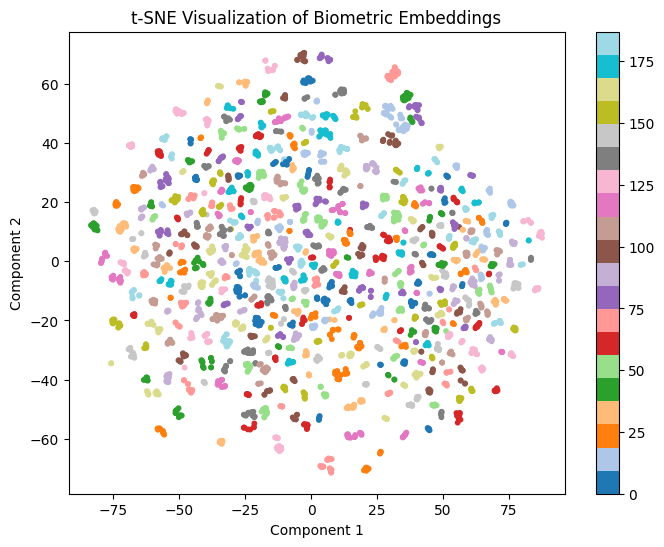

In [37]:
# ============================================================
# STEP 24 — t-SNE EMBEDDING VISUALIZATION
# ============================================================

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

embeddings = all_embeddings
labels = all_labels

tsne = TSNE(n_components=2, perplexity=30, random_state=42)

embeddings_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    embeddings_2d[:,0],
    embeddings_2d[:,1],
    c=labels,
    cmap="tab20",
    s=10
)

plt.title("t-SNE Visualization of Biometric Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")

plt.colorbar(scatter)

plt.show()